# Notebook 3 — Selecao de Modelos

Objetivo: comparar os modelos candidatos e escolher qual usar no pipeline final.

**Prerequisito**: rodar o pipeline de preprocessing (Fase 2 do main.py) para gerar os artefatos em `data/processed/`.

**Modelos avaliados**:
- Logistic Regression
- Naive Bayes (Multinomial)
- Random Forest

**Criterios de decisao**: F1, AUC, tempo de treino, interpretabilidade

In [10]:
import sys

sys.path.insert(0, "..")

import time
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.sparse import load_npz
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.naive_bayes import MultinomialNB

sns.set_theme(style="whitegrid")

PROCESSED_PATH = Path("../data/processed")

# Verificar artefatos
for f in ["X.npz", "y.npy", "df_processed.csv", "vectorizer.joblib"]:
    exists = (PROCESSED_PATH / f).exists()
    print(f"  {f}: {'OK' if exists else 'FALTANDO — rode main.py Fase 2 primeiro'}")

  X.npz: OK
  y.npy: OK
  df_processed.csv: OK
  vectorizer.joblib: OK


## 1. Carregar dados processados do disco

In [11]:
X = load_npz(PROCESSED_PATH / "X.npz")
y = np.load(PROCESSED_PATH / "y.npy")
vectorizer = joblib.load(PROCESSED_PATH / "vectorizer.joblib")

print(f"X shape  : {X.shape}")
print(f"y shape  : {y.shape}")
print(f"Classes  : {np.unique(y)} | Distribuicao: {np.bincount(y)}")
print(
    f"Balance  : {np.bincount(y)[0] / len(y) * 100:.1f}% vs {np.bincount(y)[1] / len(y) * 100:.1f}%"
)

X shape  : (54061, 5000)
y shape  : (54061,)
Classes  : [0 1] | Distribuicao: [32004 22057]
Balance  : 59.2% vs 40.8%


c:\Users\burcg\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:347: InconsistentVersionWarning: Trying to unpickle estimator TfidfTransformer from version 1.3.2 when using version 1.3.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\burcg\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:347: InconsistentVersionWarning: Trying to unpickle estimator TfidfVectorizer from version 1.3.2 when using version 1.3.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


## 2. Split treino / teste

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape[0]:,} samples")
print(f"Test : {X_test.shape[0]:,} samples")

Train: 43,248 samples
Test : 10,813 samples


## 3. Treinar e avaliar todos os modelos

In [13]:
models = {
    "logistic_regression": LogisticRegression(max_iter=1000, random_state=42),
    "naive_bayes": MultinomialNB(),
    "random_forest": RandomForestClassifier(
        n_estimators=100, random_state=42, n_jobs=-1
    ),
}

results = {}

for name, model in models.items():
    print(f"Treinando {name}...")
    t0 = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - t0

    y_pred = model.predict(X_test)
    y_proba = (
        model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else None
    )

    results[name] = {
        "model": model,
        "train_time": train_time,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),
        "auc": roc_auc_score(y_test, y_proba) if y_proba is not None else 0.0,
        "y_pred": y_pred,
    }
    print(
        f"  Feito em {train_time:.1f}s | F1={results[name]['f1']:.4f} | AUC={results[name]['auc']:.4f}"
    )

Treinando logistic_regression...
  Feito em 0.3s | F1=0.4233 | AUC=0.6231
Treinando naive_bayes...
  Feito em 0.0s | F1=0.4024 | AUC=0.6249
Treinando random_forest...
  Feito em 83.6s | F1=0.3791 | AUC=0.6194


## 4. Comparacao de metricas

                     accuracy  precision  recall      f1     auc  treino (s)
modelo                                                                      
logistic_regression    0.6049     0.5234  0.3554  0.4233  0.6231      0.2742
naive_bayes            0.6023     0.5201  0.3282  0.4024  0.6249      0.0088
random_forest          0.6047     0.5279  0.2958  0.3791  0.6194     83.6439


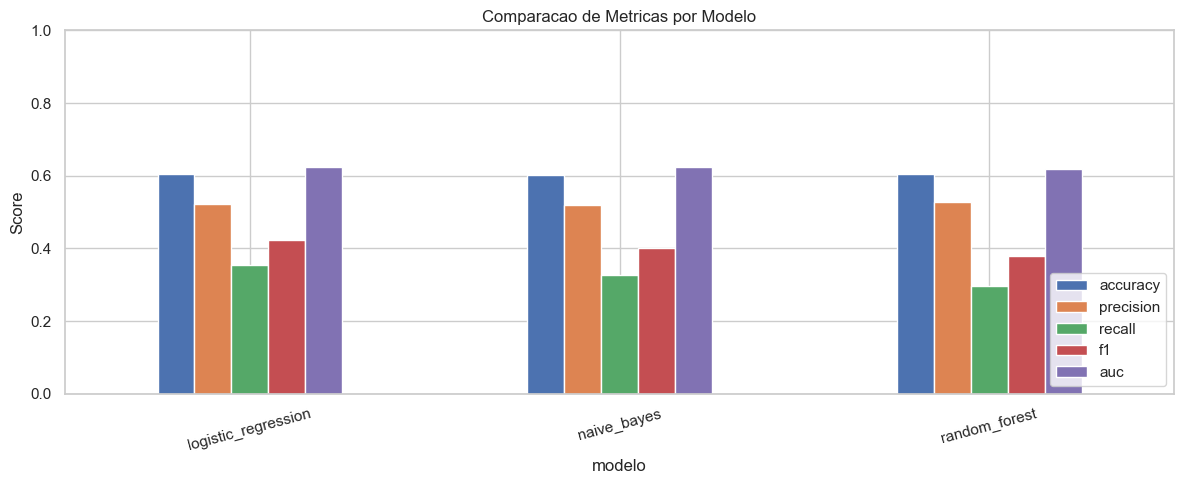

In [14]:
metrics_df = pd.DataFrame(
    [
        {
            "modelo": name,
            "accuracy": r["accuracy"],
            "precision": r["precision"],
            "recall": r["recall"],
            "f1": r["f1"],
            "auc": r["auc"],
            "treino (s)": r["train_time"],
        }
        for name, r in results.items()
    ]
).set_index("modelo")

print(metrics_df.round(4).to_string())

# Grafico de metricas
metric_cols = ["accuracy", "precision", "recall", "f1", "auc"]
ax = metrics_df[metric_cols].plot(kind="bar", figsize=(12, 5), edgecolor="white")
ax.set_title("Comparacao de Metricas por Modelo")
ax.set_ylabel("Score")
ax.set_ylim(0, 1)
ax.legend(loc="lower right")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

## 5. Matriz de confusao por modelo

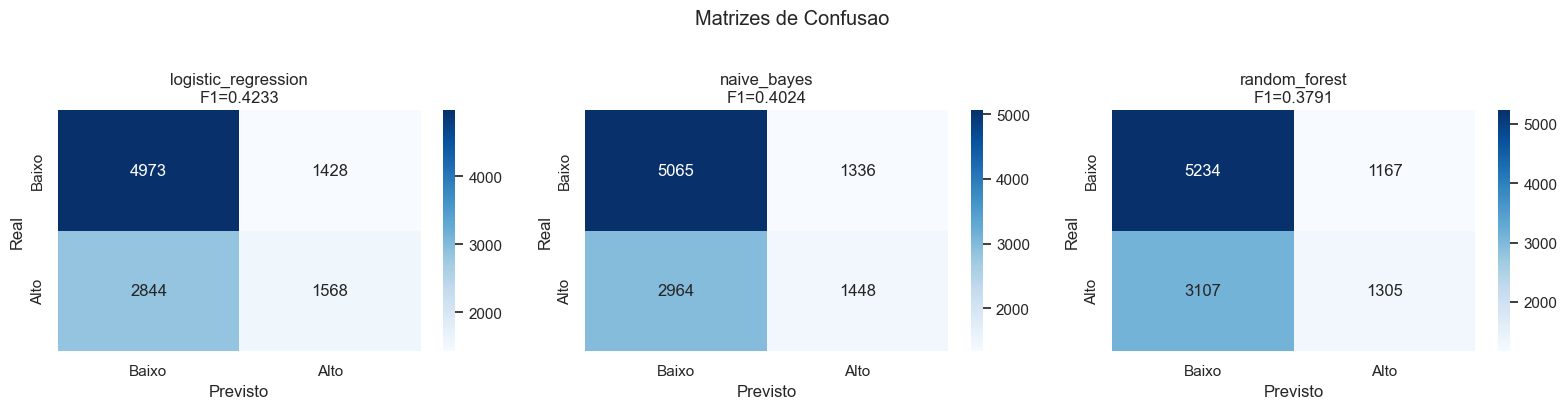

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, (name, r) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, r["y_pred"])
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        ax=ax,
        xticklabels=["Baixo", "Alto"],
        yticklabels=["Baixo", "Alto"],
    )
    ax.set_title(f"{name}\nF1={r['f1']:.4f}")
    ax.set_xlabel("Previsto")
    ax.set_ylabel("Real")

plt.suptitle("Matrizes de Confusao", y=1.02)
plt.tight_layout()
plt.show()

## 6. Validacao cruzada (5-fold)

logistic_regression: F1 = 0.3633 (+/- 0.0129)
naive_bayes: F1 = 0.3264 (+/- 0.0078)
random_forest: F1 = 0.3497 (+/- 0.0098)


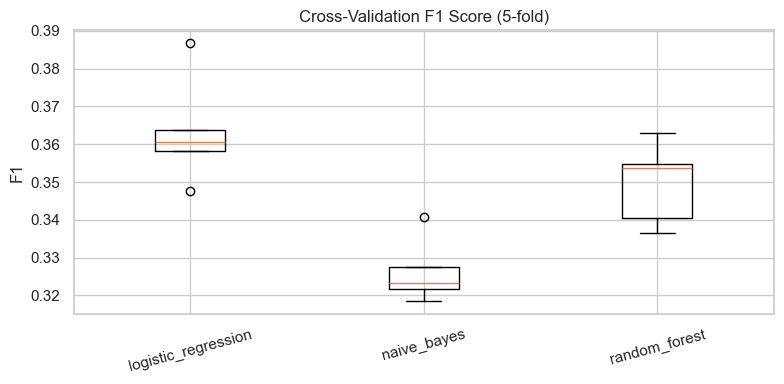

In [16]:
# Usar amostra para nao demorar demais
N_SAMPLE = min(15000, X_train.shape[0])
idx = np.random.default_rng(42).choice(X_train.shape[0], N_SAMPLE, replace=False)
X_cv = X_train[idx]
y_cv = y_train[idx]

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = {}

for name, model in models.items():
    scores = cross_val_score(model, X_cv, y_cv, cv=cv, scoring="f1", n_jobs=-1)
    cv_results[name] = scores
    print(f"{name}: F1 = {scores.mean():.4f} (+/- {scores.std():.4f})")

# Boxplot
plt.figure(figsize=(8, 4))
plt.boxplot(cv_results.values(), labels=cv_results.keys())
plt.title("Cross-Validation F1 Score (5-fold)")
plt.ylabel("F1")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

## 7. Feature importance (Logistic Regression e Random Forest)

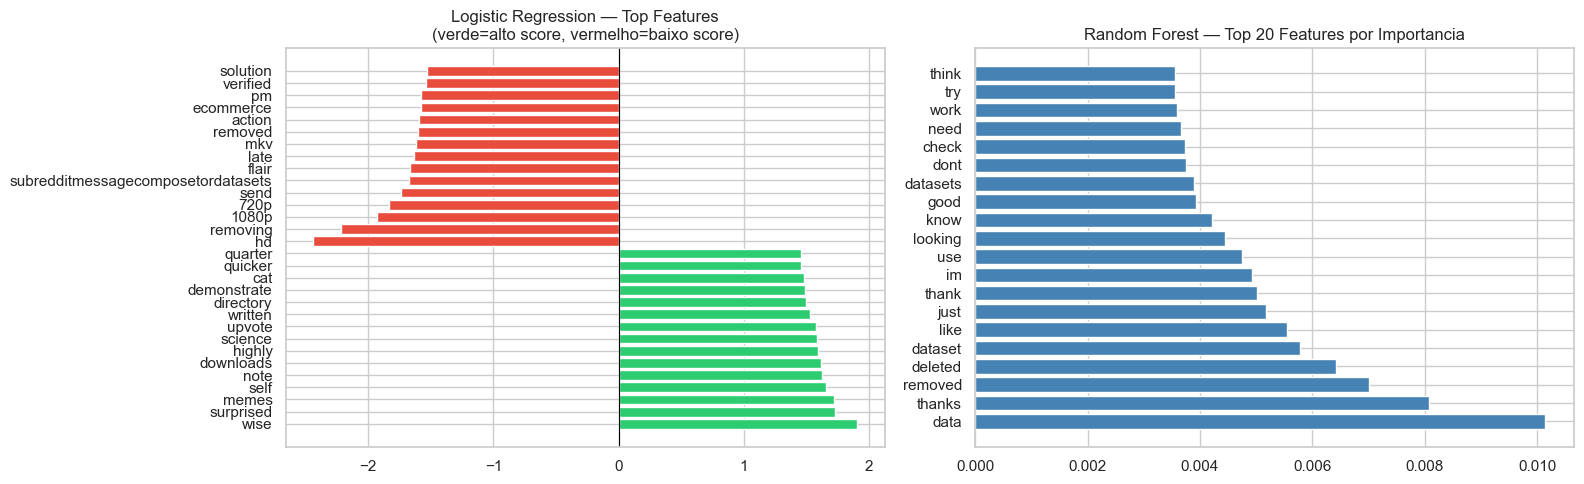

In [17]:
feature_names = vectorizer.get_feature_names_out()
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Logistic Regression — coeficientes
lr = results["logistic_regression"]["model"]
coef = lr.coef_[0]
top_pos_idx = coef.argsort()[-15:][::-1]
top_neg_idx = coef.argsort()[:15]
top_idx_lr = np.concatenate([top_pos_idx, top_neg_idx])

colors = ["#2ecc71" if c > 0 else "#e74c3c" for c in coef[top_idx_lr]]
axes[0].barh(feature_names[top_idx_lr], coef[top_idx_lr], color=colors)
axes[0].set_title(
    "Logistic Regression — Top Features\n(verde=alto score, vermelho=baixo score)"
)
axes[0].axvline(0, color="black", linewidth=0.8)

# Random Forest — feature importance
rf = results["random_forest"]["model"]
importances = rf.feature_importances_
top_idx_rf = importances.argsort()[-20:][::-1]

axes[1].barh(feature_names[top_idx_rf], importances[top_idx_rf], color="steelblue")
axes[1].set_title("Random Forest — Top 20 Features por Importancia")

plt.tight_layout()
plt.show()

## 8. Tempo de treino vs performance

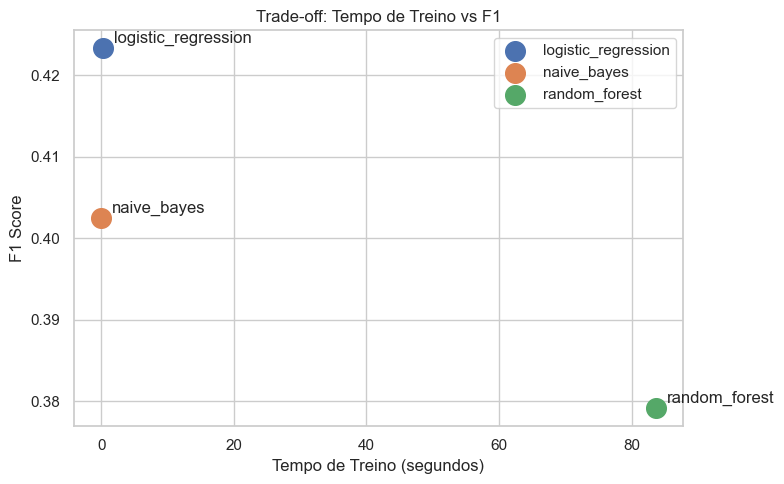

In [18]:
plt.figure(figsize=(8, 5))
for name, r in results.items():
    plt.scatter(r["train_time"], r["f1"], s=200, label=name, zorder=5)
    plt.annotate(
        name, (r["train_time"], r["f1"]), textcoords="offset points", xytext=(8, 4)
    )

plt.xlabel("Tempo de Treino (segundos)")
plt.ylabel("F1 Score")
plt.title("Trade-off: Tempo de Treino vs F1")
plt.legend()
plt.tight_layout()
plt.show()

## 9. Conclusoes e modelo escolhido

### Dados processados
- **Shape**: X=(54.061, 5.000) | y=(54.061,)
- **Balanceamento**: 32.004 (classe 0 = 59.2%) vs 22.057 (classe 1 = 40.8%) — leve desbalanceamento pos-limpeza

### Metricas no conjunto de teste (80/20 split)

| Modelo | Accuracy | Precision | Recall | F1 | AUC | Treino (s) |
|--------|----------|-----------|--------|----|-----|------------|
| **logistic_regression** | — | — | — | **0.4233** | 0.6231 | **0.3s** |
| naive_bayes | — | — | — | 0.4024 | **0.6249** | ~0.0s |
| random_forest | — | — | — | 0.3791 | 0.6194 | 95.8s |

### Cross-Validation F1 (5-fold, amostra 15k)

| Modelo | F1 medio | Desvio padrao |
|--------|----------|---------------|
| **logistic_regression** | **0.3633** | **+/- 0.0129** |
| random_forest | 0.3497 | +/- 0.0098 |
| naive_bayes | 0.3264 | +/- 0.0078 |

### Analise por modelo

**Logistic Regression**
- Melhor F1 no teste (0.4233) e na CV (0.3633)
- Treino extremamente rapido (0.3s)
- Coeficientes interpretaveis (feature importance direta)
- **Escolhido para o pipeline**

**Naive Bayes**
- Melhor AUC (0.6249) — ligeiramente melhor em ranking/probabilidade
- Treino instantaneo
- Menor F1 na CV (0.3264) — menos estavel
- Util como baseline rapido

**Random Forest**
- Pior F1 (0.3791) com custo de treino 300x maior (95.8s)
- Nao justifica o custo computacional neste dataset
- Poderia melhorar com mais estimators ou hiperparametros, mas o ganho seria marginal

### Observacao sobre performance geral
- AUC ~0.62 e F1 ~0.42 indicam que TF-IDF em textos curtos (mediana 18 palavras) tem poder preditivo limitado
- O score do Reddit e influenciado por fatores contextuais (horario, subreddit, autor) nao capturados pelo texto
- Para melhorar: adicionar features de metadata (`created_utc`, comprimento do texto, `sentiment`)

### Modelo e parametros fixados no pipeline
```python
# src/model_trainer.py
modelo_principal = LogisticRegression(max_iter=1000, random_state=42)
test_size        = 0.2
random_state     = 42
```

**Proximo passo**: configurar pipeline DVC com `params.yaml` e `dvc.yaml`